[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/seap-udea/MontuPython/blob/main/examples/MontuPython-SolarEclipses.ipynb)

<p align="left"><img src="https://github.com/seap-udea/MontuPython/raw/main/montu/data/montu-python-logo-complete.webp" width="300" /></p>

# Solar Eclipses Examples

This notebook shows how MontuPython predicts **local circumstances** of solar eclipses from the NASA Five Millennium Catalog of Solar Eclipses (Espenak & Meeus).

**Notes**: Catalogue dates use the calendar conventions of the NASA Five Millennium Canon. In MontuPython, convert the returned Julian Day with `calendar='mixed'` to recover those historical civil dates. Local circumstances use the catalogue ΔT and do **not** apply a lunar-limb profile, so path edges can be off by a few kilometres.

If running in Google Colab, MontuPython must be installed first. In a local copy of the repository this cell can remain commented out.

In [1]:
# %pip install -Uq montu

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import montu
import numpy as np
import pandas as pd

pd.options.display.float_format = "{:.3f}".format

MontuPython version 0.22.1. 𓇍𓇋𓇋𓏏𓅓𓊵 𓎛𓎡𓄿𓀭𓎛𓈖𓂝𓎡 (ii-ti m Htp, HkAx Hn'-k)


## 1. Setup and conventions

The eclipse engine returns:

- **`kind`**: `none`, `partial`, `annular`, or `total` at the site;
- **`visible`**: eclipse occurs locally *and* the Sun is above the horizon at maximum;
- **`magnitude`**: fraction of the solar *diameter* covered;
- **`obscuration`**: fraction of the solar *disk area* covered;
- contact Julian Days `jed_c1`…`jed_c4` (UTC) and `time_max` as a `montu.Time`.

Data sources: https://eclipse.gsfc.nasa.gov/SEcat5/SEcatalog.html

## 2. The eclipse catalogue

`SolarEclipses` loads NASA's polynomial Besselian elements for **11 898** solar eclipses from **−1999 to +3000**. Filtering uses the same conventions as `Stars.get_stars`:

- a scalar matches a column exactly;
- a two-element list `[min, max]` is an inclusive range;
- a tuple is an OR condition.

`get_eclipse` is an alias of `get_eclipses`.

In [3]:
eclipses = montu.SolarEclipses()
eclipses.data

,year,month,day,td_ge,dt,luna_num,saros,eclipse_type,gamma,magnitude,...,tan_f2,tmin,tmax,etype,PNS,UNS,NCN,nSer,nSeq,nJLE
0,-1999,6,12,03:14:51,46438.200,-49456,5,T,-0.270,1.073,...,0.005,-3.000,3.000,1,0,0,0,73,41,4
1,-1999,12,5,23:45:23,46426.500,-49450,10,A,-0.232,0.938,...,0.005,-3.000,3.000,2,0,0,0,73,27,40
2,-1998,6,1,18:09:16,46414.600,-49444,15,T,0.499,1.028,...,0.005,-3.000,3.000,1,1,0,0,75,32,20
3,-1998,11,25,05:57:03,46402.800,-49438,20,A,-0.905,0.981,...,0.005,-3.000,3.000,2,-1,0,0,72,17,20
4,-1997,4,22,13:19:56,46392.900,-49433,-13,P,-1.467,0.161,...,0.005,-3.000,3.000,4,-1,-1,-1,73,72,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11893,2998,12,10,03:18:31,4413.600,12355,187,P,1.284,0.477,...,0.005,-3.000,3.000,4,1,1,1,70,8,10
11894,2999,5,6,23:23:57,4416.600,12360,154,T,0.839,1.057,...,0.005,-3.000,3.000,1,1,0,0,71,61,2
11895,2999,10,30,09:34:33,4420.300,12366,159,A-,-1.002,0.959,...,0.005,-3.000,3.000,2,-1,-1,-1,70,49,1
11896,3000,4,26,14:18:06,4424.000,12372,164,T,0.131,1.022,...,0.005,-3.000,3.000,1,0,0,0,80,51,4


We can count the number of eclipses of each type:

In [4]:
eclipses.data.eclipse_type.value_counts().head()

eclipse_type
P     3875
A     3755
T     3049
H      502
Pb     163
Name: count, dtype: int64

We can filter with different criteria:

In [5]:
window = eclipses.get_eclipses(year=[-1400, -1200], eclipse_type="T")
window.number

126

Basic information is:

In [6]:
window.data[[
    "year", "month", "day", "td_ge", "eclipse_type",
    "gamma", "magnitude", "lat_dd_ge", "lng_dd_ge", "duration_secs",
]].head(8)

,year,month,day,td_ge,eclipse_type,gamma,magnitude,lat_dd_ge,lng_dd_ge,duration_secs
1427,-1399,3,12,07:05:11,T,-0.454,1.055,-31.918,-130.456,254.000
1430,-1398,8,24,21:37:16,T,-0.153,1.024,7.717,-9.816,138.000
1432,-1397,8,14,12:45:34,T,-0.853,1.055,-36.368,104.661,262.500
1437,-1395,12,18,00:18:52,T,0.256,1.028,-8.178,-47.494,170.500
1439,-1394,12,7,15:40:19,T,0.913,1.036,44.783,87.717,171.000
1443,-1392,4,22,06:44:14,T,0.704,1.026,49.638,-163.166,122.600
1445,-1391,4,11,21:43:28,T,-0.068,1.073,-0.305,-7.094,391.300
1447,-1390,4,1,14:50:14,T,-0.800,1.062,-50.384,119.192,262.200


Explanation of the columns in the DataFrame above:

- year: year in the Gregorian calendar (negative = BCE)
- month: month when the eclipse occurs (1-12)
- day: day of the month the eclipse occurs
- td_ge: time of maximum eclipse in Dynamical Time (TD), format HH:MM:SS
- eclipse_type: type of eclipse; can be:
    - T: total
    - A: annular
    - H: hybrid
    - P: partial
    - Pb: partial without umbra
- gamma: angular distance between the shadow axis and Earth's center (in Earth radii)
- magnitude: fraction of the Sun’s diameter covered at the maximum phase of the eclipse
- lat_dd_ge: geographic latitude of the maximum eclipse location (decimal degrees)
- lng_dd_ge: geographic longitude of the maximum eclipse location (decimal degrees, east positive)
- duration_secs: duration of the total or annular phase at maximum, in seconds (NaN if not applicable)

## 3. Modern validation: Dallas, 2024 April 8

Before trusting ancient predictions, we check a well-observed modern event. Downtown Dallas lay inside the path of totality; published circumstances give about **3 min 51 s** of totality and magnitude ≈ **1.015**.

In [7]:
eclipse_2024 = eclipses.get_eclipses(year=2024, eclipse_type='T').eclipse(0)
dallas = montu.Observer(lon=-96.7970, lat=32.7767, height=0.14)
cond_dallas = eclipse_2024.conditions_eclipse(dallas)

#print(eclipse_2024)
print(f"kind            : {cond_dallas.kind}")
print(f"visible         : {cond_dallas.visible}")
print(f"magnitude       : {cond_dallas.magnitude:.5f}")
print(f"obscuration     : {cond_dallas.obscuration:.5f}")
print(f"duration (umbra): {montu.D2H(cond_dallas.duration_umbra_seconds / 3600)} h:m:s")
print(f"sun altitude    : {cond_dallas.sun_altitude_deg:.1f}°")
print(f"maximum (UTC)   : {cond_dallas.time_max.readable.datepro}")

kind            : total
visible         : True
magnitude       : 1.01450
obscuration     : 1.00000
duration (umbra): 00:03:49.491 h:m:s
sun altitude    : 64.7°
maximum (UTC)   : 2024-04-08 18:42:46.399678


You can validate this result using the catalogue of eclipses of Xavier Jubier: http://xjubier.free.fr/en/site_pages/solar_eclipses/xSE_GoogleMap3.php?Ecl=+20240408&Acc=2&Umb=1&Lmt=1&Mag=0&Lat=32.7767&Lng=-96.7970&Elv=140.0&Zoom=9&LC=1

And the contacts are:

In [8]:
def contact_label(jed):
    if jed is None:
        return None
    return montu.Time(jed, format="jd").readable.datepro

pd.DataFrame([
    {"contact": "C1 (partial begins)", "utc": contact_label(cond_dallas.jed_c1)},
    {"contact": "C2 (totality begins)", "utc": contact_label(cond_dallas.jed_c2)},
    {"contact": "Maximum", "utc": contact_label(cond_dallas.jed_max)},
    {"contact": "C3 (totality ends)", "utc": contact_label(cond_dallas.jed_c3)},
    {"contact": "C4 (partial ends)", "utc": contact_label(cond_dallas.jed_c4)},
])

,contact,utc
0,C1 (partial begins),2024-04-08 17:23:26.295342
1,C2 (totality begins),2024-04-08 18:40:51.600019
2,Maximum,2024-04-08 18:42:46.399678
3,C3 (totality ends),2024-04-08 18:44:41.095697
4,C4 (partial ends),2024-04-08 20:02:48.900485


The same eclipse is only a night-time partial event in Egypt — a useful sanity check that geography and solar altitude enter the visibility flag.

In [9]:
thebes = montu.Observer(site="thebes")
cond_thebes_2024 = eclipse_2024.conditions_eclipse(thebes)
{
    "kind": cond_thebes_2024.kind,
    "visible": cond_thebes_2024.visible,
    "magnitude": cond_thebes_2024.magnitude,
    "sun_altitude_deg": cond_thebes_2024.sun_altitude_deg,
}

{'kind': 'partial',
 'visible': False,
 'magnitude': 0.7855642979648575,
 'sun_altitude_deg': -42.56861960190191}

## 5. Eclipses visible from Thebes (−1400 to −1200)

We scan the two-century window and retain events that are locally visible with magnitude greater than 0.5. This is the typical workflow for archaeoastronomical surveys: filter the catalogue, then evaluate each candidate at the site.

In [10]:
site = montu.Observer(site="thebes")

In [11]:
rows = []
for i in range(window.number):
    eclipse_i = window.eclipse(i)
    cond_i = eclipse_i.conditions_eclipse(site)
    if not cond_i.visible or cond_i.magnitude <= 0.5:
        continue
    t_mixed = montu.Time(cond_i.jed_max, format="jd", calendar="mixed")
    # Get the canicular date using the appropriate method, assuming 'canicular' exists in montu.Time
    t_canic = montu.Time(cond_i.jed_max, format="jd", calendar="canicular")
    rows.append({
        "catalog_date": f"{cond_i.year:+05d}-{cond_i.month:02d}-{cond_i.day:02d}",
        "mixed_date": t_mixed.readable.datemix,
        "canicular_date": t_canic.readable.datesot,  # generic name, adapt if the attribute is different
        "catalog_type": cond_i.eclipse_type,
        "local_kind": cond_i.kind,
        "magnitude": cond_i.magnitude,
        "obscuration": cond_i.obscuration,
        "sun_alt_deg": cond_i.sun_altitude_deg,
        "umbra_s": cond_i.duration_umbra_seconds,
        "jed_max": cond_i.jed_max,
    })

visible = pd.DataFrame(rows).sort_values("jed_max").reset_index(drop=True)
print(f"Total visible eclipses: {len(visible)}")
visible

Total visible eclipses: 13


,catalog_date,mixed_date,canicular_date,catalog_type,local_kind,magnitude,obscuration,sun_alt_deg,umbra_s,jed_max
0,-1391-04-11,-1391-04-11 14:09:09,[hrw 1390] I shemu 9,T,partial,0.633,0.553,24.525,NaN,1213096.090
1,-1383-05-12,-1383-05-12 04:43:43,[hrw 1398] II shemu 12,T,partial,0.791,0.738,19.817,NaN,1216048.697
2,-1374-05-03,-1374-05-03 03:29:29,[hrw 1407] II shemu 5,T,partial,0.793,0.743,1.552,NaN,1219326.646
3,-1351-08-15,-1351-08-15 12:21:21,[hrw 1431] I akhet 20,T,partial,0.791,0.743,54.726,NaN,1227832.015
4,-1339-01-08,-1339-01-08 08:50:50,[hrw 1442] II peret 19,T,partial,0.787,0.741,37.983,NaN,1231995.868
5,-1337-05-14,-1337-05-14 12:12:12,[hrw 1444] II shemu 25,T,partial,0.943,0.943,53.182,NaN,1232852.009
6,-1331-12-30,-1331-12-30 07:09:09,[hrw 1451] II peret 12,T,partial,0.747,0.688,26.328,NaN,1235273.798
7,-1311-06-24,-1311-06-24 11:05:05,[hrw 1470] IV shemu 13,T,partial,0.526,0.423,70.844,NaN,1242389.962
8,-1308-10-17,-1308-10-17 05:00:00,[hrw 1474] IV akhet 4,T,partial,0.934,0.920,15.287,NaN,1243600.709
9,-1276-02-01,-1276-02-01 10:27:27,[hrw 1505] III peret 28,T,partial,0.659,0.582,43.919,NaN,1255029.935


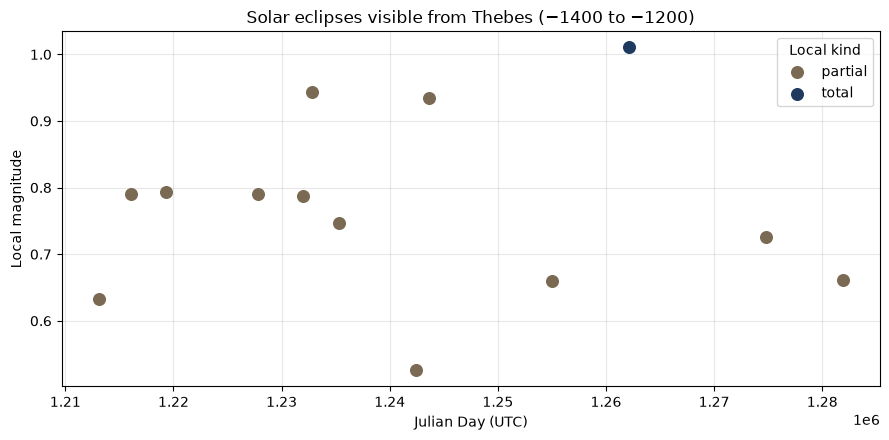

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = {"partial": "#7a6a53", "annular": "#c45c26", "total": "#1f3a5f"}
for kind, group in visible.groupby("local_kind"):
    ax.scatter(
        group["jed_max"], group["magnitude"],
        s=70, label=kind, color=colors.get(kind, "gray"), zorder=3,
    )
ax.set_xlabel("Julian Day (UTC)")
ax.set_ylabel("Local magnitude")
ax.set_title("Solar eclipses visible from Thebes (−1400 to −1200)")
ax.grid(True, alpha=0.3)
ax.legend(title="Local kind")
plt.tight_layout()
plt.show()

## 6. Case study: total eclipse of −1257 July 27 at Thebes

Among the candidates, the total eclipse of **−1257-07-27** (NASA / mixed calendar) stands out: high solar altitude, magnitude above 1, and nearly three minutes of totality. In archaeological year numbering this is the historical year **1258 BCE**.

In [13]:
eclipse_thebes = eclipses.get_eclipses(year=-1257, month=7, day=27).eclipse(0)
cond_tot = eclipse_thebes.conditions_eclipse(site)
t_max = montu.Time(cond_tot.jed_max, format="jd", calendar="mixed")

print(f"local kind      : {cond_tot.kind}")
print(f"visible         : {cond_tot.visible}")
print(f"magnitude       : {cond_tot.magnitude:.5f}")
print(f"obscuration     : {cond_tot.obscuration:.5f}")
print(f"moon/sun ratio  : {cond_tot.moon_sun_ratio:.5f}")
print(f"sun altitude    : {cond_tot.sun_altitude_deg:.1f}°")
print(f"umbra duration  : {cond_tot.duration_umbra_seconds:.1f} s")
print(f"maximum (mixed) : {t_max.readable.datemix}")
print(f"maximum (JED)   : {cond_tot.jed_max:.6f}")
print(f"ΔT (catalogue)  : {cond_tot.delta_t:.1f} s")

local kind      : total
visible         : True
magnitude       : 1.01038
obscuration     : 1.00000
moon/sun ratio  : 1.03447
sun altitude    : 70.4°
umbra duration  : 176.2 s
maximum (mixed) : -1257-07-27 08:25:25
maximum (JED)   : 1262145.850940
ΔT (catalogue)  : 30132.8 s


In [14]:
contacts = []
for label, jed in [
    ("C1", cond_tot.jed_c1),
    ("C2", cond_tot.jed_c2),
    ("Max", cond_tot.jed_max),
    ("C3", cond_tot.jed_c3),
    ("C4", cond_tot.jed_c4),
]:
    t = montu.Time(jed, format="jd", calendar="mixed")
    contacts.append({
        "contact": label,
        "mixed": t.readable.datemix,
        "jed": jed,
    })
pd.DataFrame(contacts)

,contact,mixed,jed
0,C1,-1257-07-27 06:56:56,1262145.789
1,C2,-1257-07-27 08:23:23,1262145.850
2,Max,-1257-07-27 08:25:25,1262145.851
3,C3,-1257-07-27 08:26:26,1262145.852
4,C4,-1257-07-27 10:02:02,1262145.919


### 6.1 Compare neighbouring Egyptian sites

Path width is only of order 100–200 km, so Memphis and Thebes need not share the same local kind. Evaluating the same eclipse at several catalogue sites makes that geographic dependence concrete.

In [15]:
sites = ["thebes", "memphis", "giza", "alexandria"]
comparison = []
for site_id in sites:
    obs = montu.Observer(site=site_id)
    c = eclipse_thebes.conditions_eclipse(obs)
    comparison.append({
        "site": site_id,
        "lat": obs.lat,
        "lon": obs.lon,
        "kind": c.kind,
        "visible": c.visible,
        "magnitude": c.magnitude,
        "umbra_s": c.duration_umbra_seconds,
        "sun_alt_deg": c.sun_altitude_deg,
    })
pd.DataFrame(comparison)

,site,lat,lon,kind,visible,magnitude,umbra_s,sun_alt_deg
0,thebes,25.697,32.642,total,True,1.010,176.150,70.392
1,memphis,29.846,31.251,partial,True,0.884,NaN,68.134
2,giza,29.979,31.134,partial,True,0.879,NaN,67.962
3,alexandria,31.200,29.919,partial,True,0.835,NaN,66.210


## 7. Compact recipe

The usual three-line pattern for historical work:

In [16]:
eclipses = montu.SolarEclipses()
candidates = eclipses.get_eclipses(year=[-1400, -1200], eclipse_type=("T", "A", "H"))
site = montu.Observer(site="thebes")

for i in range(min(3, candidates.number)):
    eclipse = candidates.eclipse(i)
    cond = eclipse.conditions_eclipse(site)
    t = montu.Time(cond.jed_max, format="jd", calendar="mixed")
    print(
        f"{eclipse.__repr__()}  local={cond.kind:8s}  "
        f"mag={cond.magnitude:6.3f}  visible={cond.visible}  "
        f"max={t.readable.datemix}"
    )

<SolarEclipse -1399-03-12 type=T>  local=none      mag= 0.000  visible=False  max=-1399-03-11 22:00:00
<SolarEclipse -1399-09-04 type=A>  local=partial   mag= 0.211  visible=False  max=-1399-09-04 01:19:19
<SolarEclipse -1398-03-01 type=H>  local=annular   mag= 0.998  visible=True  max=-1398-03-01 12:25:25


## Attribution

Eclipse predictions in the bundled catalogue follow Fred Espenak, NASA GSFC (*Five Millennium Canon of Solar Eclipses*). Local circumstances in MontuPython implement the fundamental-plane reduction from the *Explanatory Supplement to the Astronomical Almanac* and Meeus, *Elements of Solar Eclipses*.

𓇍𓇋𓇋𓏏𓅓𓊵 𓎛𓎡𓄿𓀭𓎛𓈖𓂝𓎡

---
*Powered by MontuPython*. For more examples see [MontuPython GitHub repo](https://github.com/seap-udea/MontuPython/tree/main/examples).

Jorge I. Zuluaga © 2023-present